# MINE 4201 - Laboratorio 3 V6: Sistemas de Recomendación con SVD

En este laboratorio aprenderá el flujo completo de SVD en sistemas de recomendación: primero la intuición algebraica, luego la factorización con Surprise y finalmente un ejercicio con scikit-learn.

## Objetivos de aprendizaje
1. Comprender la matriz usuario-item y por qué su alta dispersión motiva los modelos de factores latentes.
2. Desarrollar intuición sobre SVD descomponiendo una matriz pequeña paso a paso.
3. Entrenar un modelo SVD con sesgos usando la librería **Surprise**.
4. Reconstruir manualmente la matriz de ratings y verificar la fórmula de predicción.
5. Evaluar el efecto de los hiperparámetros $k$ (factores latentes) y la regularización.
6. Entender el papel de los sesgos (*biases*) en la calidad del modelo.
7. Implementar SVD con una librería moderna (**scikit-learn**) como alternativa a Surprise.

## Cómo trabajar este notebook
- Las celdas ya resueltas construyen contexto y preparan las variables.
- Las celdas marcadas como **TODO** deben completarse por el estudiante.
- Cada ejercicio está dividido en pasos pequeños. Si una celda depende de otra, ejecútelas en orden.
- Antes de seguir, trate de explicar con sus palabras qué representa cada matriz o vector.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
from surprise import Dataset, Reader, SVD, accuracy

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Carga y exploración de los datos

Los archivos ya están separados en **entrenamiento**, **validación** y **prueba**. Empezamos verificando su estructura, dimensiones y distribución de ratings.

In [2]:
DATA_PATH = Path("data")
COLUMNS = ["user_id", "item_id", "rating", "timestamp"]

train_df = pd.read_csv(DATA_PATH / "train", sep="::", names=COLUMNS, engine="python")
validation_df = pd.read_csv(DATA_PATH / "validation", sep="::", names=COLUMNS, engine="python")
test_df = pd.read_csv(DATA_PATH / "test", sep="::", names=COLUMNS, engine="python")
movies_df = pd.read_csv(DATA_PATH / "movies.csv")

In [3]:
# Resumen rápido de los tres conjuntos
summary_df = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n_ratings": [len(train_df), len(validation_df), len(test_df)],
    "n_users": [train_df["user_id"].nunique(), validation_df["user_id"].nunique(), test_df["user_id"].nunique()],
    "n_items": [train_df["item_id"].nunique(), validation_df["item_id"].nunique(), test_df["item_id"].nunique()],
})
summary_df

,split,n_ratings,n_users,n_items
0,train,81140,911,1672
1,validation,9430,943,1129
2,test,9430,943,1145


### Ejercicio 1.1 — Calcular la dispersión de la matriz usuario-item

La **dispersión** (*sparsity*) mide qué fracción de la matriz usuario-item **no** tiene ratings.
Si la matriz tiene $m$ usuarios y $n$ ítems, hay $m \times n$ posibles entradas.

$$\text{sparsity} = 1 - \frac{\text{ratings observados}}{m \times n}$$

In [6]:
# TODO: Calcule el número de usuarios, ítems, ratings y la dispersión
n_users = train_df["user_id"].nunique()
n_items = train_df["item_id"].nunique()
n_ratings = len(train_df)
sparsity = 1 - (n_ratings / (n_users * n_items))

print(f"Usuarios: {n_users}")
print(f"Ítems:    {n_items}")
print(f"Ratings:  {n_ratings}")
print(f"Tamaño de la matriz: {n_users} x {n_items} = {n_users * n_items:,} entradas posibles")
print(f"Dispersión: {sparsity:.4%}")

Usuarios: 911
Ítems:    1672
Ratings:  81140
Tamaño de la matriz: 911 x 1672 = 1,523,192 entradas posibles
Dispersión: 94.6730%


### Ejercicio 1.2 — Distribución de ratings

Visualice la distribución de ratings en los tres conjuntos. Esto ayuda a entender si hay un sesgo natural hacia calificaciones altas o bajas.

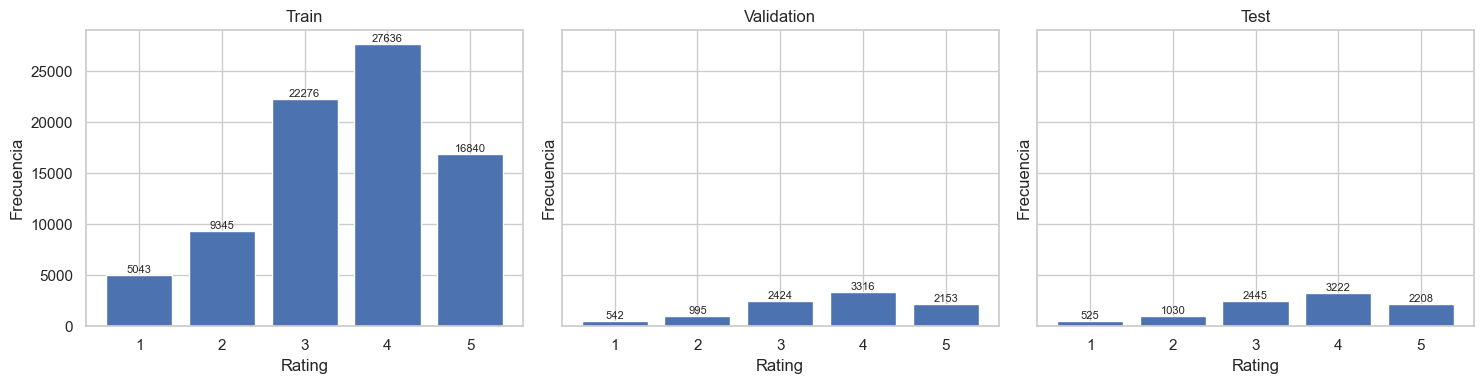

In [8]:
# TODO: Cree un gráfico de barras con la distribución de ratings para cada conjunto
# Pista: use plt.subplots(1, 3, ...) para crear 3 subfiguras lado a lado
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (name, df) in zip(axes, [("Train", train_df), ("Validation", validation_df), ("Test", test_df)]):
    rating_counts = df["rating"].value_counts().sort_index()

    bars = ax.bar(rating_counts.index, rating_counts.values)
    ax.set_title(f"{name}")
    ax.set_xlabel("Rating")
    ax.set_ylabel("Frecuencia")
    ax.set_xticks(rating_counts.index)

    for bar, value in zip(bars, rating_counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(value),
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.show()

### Visualización: submatriz usuario-item

No es práctico dibujar la matriz completa, pero sí una submuestra que ayuda a ver dónde hay ratings (colores) y dónde faltan (ceros).

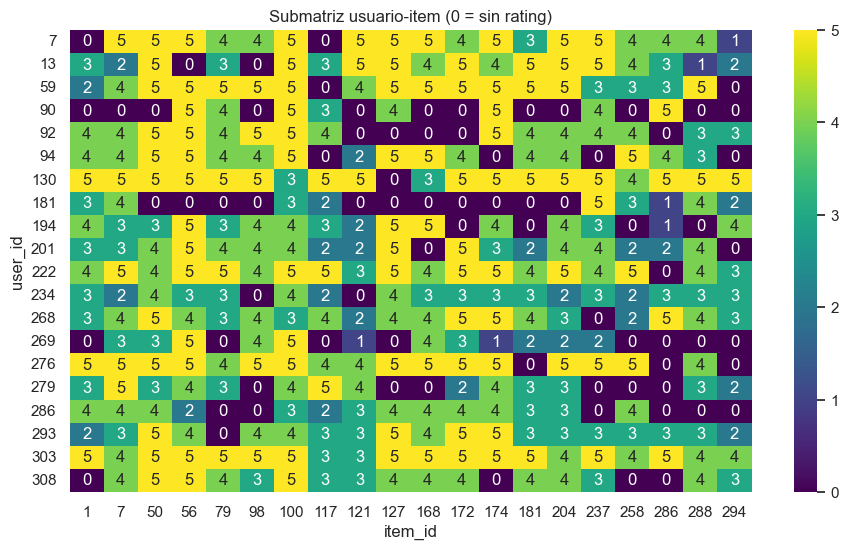

In [9]:
sample_users = train_df["user_id"].drop_duplicates().head(20)
sample_items = train_df["item_id"].value_counts().head(20).index

sample_matrix = (
    train_df[train_df["user_id"].isin(sample_users) & train_df["item_id"].isin(sample_items)]
    .pivot_table(index="user_id", columns="item_id", values="rating")
    .fillna(0)
)

plt.figure(figsize=(11, 6))
sns.heatmap(sample_matrix, cmap="viridis", annot=True, fmt=".0f")
plt.title("Submatriz usuario-item (0 = sin rating)")
plt.xlabel("item_id")
plt.ylabel("user_id")
plt.show()

## 2. Intuición de SVD con una matriz pequeña

Antes de entrenar un recomendador, conviene practicar SVD en una matriz controlada.

### ¿Qué es la Descomposición en Valores Singulares (SVD)?

Toda matriz $R$ de tamaño $m \times n$ puede descomponerse como:

$$R = U \Sigma V^T$$

donde:
- $U$ es de tamaño $m \times r$ (vectores singulares izquierdos — representan a las **filas/usuarios**).
- $\Sigma$ es una matriz diagonal $r \times r$ con los **valores singulares** $\sigma_1 \geq \sigma_2 \geq \ldots \geq \sigma_r \geq 0$.
- $V^T$ es de tamaño $r \times n$ (vectores singulares derechos — representan a las **columnas/ítems**).

La **aproximación de rango bajo** consiste en quedarse solo con los $k$ valores singulares más grandes:

$$R \approx R_k = U_k \Sigma_k V_k^T$$

Esto captura la **estructura dominante** de la matriz con menos parámetros.

In [10]:
# Matriz pequeña de ejemplo: 5 usuarios, 4 ítems
toy_matrix = np.array([
    [5.0, 4.0, 0.0, 1.0],
    [4.0, 5.0, 0.0, 1.0],
    [1.0, 1.0, 0.0, 5.0],
    [0.0, 0.0, 5.0, 4.0],
    [0.0, 0.0, 4.0, 5.0],
])

print("Forma de la matriz:", toy_matrix.shape)
pd.DataFrame(toy_matrix, columns=["Item A", "Item B", "Item C", "Item D"],
             index=["User 1", "User 2", "User 3", "User 4", "User 5"])

Forma de la matriz: (5, 4)


,Item A,Item B,Item C,Item D
User 1,5.0,4.0,0.0,1.0
User 2,4.0,5.0,0.0,1.0
User 3,1.0,1.0,0.0,5.0
User 4,0.0,0.0,5.0,4.0
User 5,0.0,0.0,4.0,5.0


### Ejercicio 2.1 — Descomposición SVD exacta

Obtenga la descomposición SVD de `toy_matrix` con `np.linalg.svd`.
Revise las formas de $U$, $s$ y $V^T$.

**Pregunta:** ¿Cuántos valores singulares obtiene? ¿Coincide con el rango de la matriz?

In [11]:
# TODO: Obtenga la descomposición SVD de toy_matrix
# Use np.linalg.svd(toy_matrix, full_matrices=False)
U, s, Vt = np.linalg.svd(toy_matrix, full_matrices=False)

print(f"U  shape: {U.shape}")
print(f"s  shape: {s.shape}")
print(f"Vt shape: {Vt.shape}")
print()
print("Valores singulares:", np.round(s, 4))

U  shape: (5, 4)
s  shape: (4,)
Vt shape: (4, 4)

Valores singulares: [10.3817  8.5937  3.22    1.    ]


### Ejercicio 2.2 — Verificar la descomposición

Reconstruya la matriz multiplicando $U \cdot \text{diag}(s) \cdot V^T$ y compare con la original.

**Pista:** use `np.diag(s)` para construir la matriz diagonal.

In [12]:
# TODO: Reconstruya la matriz usando U, s y Vt
# Pista: reconstructed = U @ np.diag(s) @ Vt
reconstructed = U @ np.diag(s) @ Vt
error_full = np.linalg.norm(toy_matrix - reconstructed)

print(f"Error de reconstrucción completa (norma Frobenius): {error_full:.2e}")

Error de reconstrucción completa (norma Frobenius): 1.47e-14


### Ejercicio 2.3 — Aproximación de rango bajo ($k = 2$)

Construya una aproximación usando solo los primeros $k = 2$ valores singulares.
Calcule el error de reconstrucción.

**Pregunta:** ¿Qué información se pierde? ¿Es mucha o poca?

In [13]:
# TODO: Construya la aproximación de rango k=2
# 1. Cree Sigma_k con los primeros k valores singulares
# 2. Multiplique U[:, :k] @ Sigma_k @ Vt[:k, :]
k = 2
Sigma_k = np.diag(s[:k])
toy_rank_k = U[:, :k] @ Sigma_k @ Vt[:k, :]
reconstruction_error = np.linalg.norm(toy_matrix - toy_rank_k)

print(f"Error de reconstrucción con k={k}: {reconstruction_error:.4f}")

Error de reconstrucción con k=2: 3.3718


Al usar 𝑘 = 2, se conservan los patrones dominantes de la matriz, pero se pierde información más específica sobre ciertas diferencias entre usuarios e ítems. Dado que el error de reconstrucción es 3.3718, la pérdida de información es moderada: la aproximación resume bien la estructura general, aunque no conserva todos los detalles.

### Ejercicio 2.4 — Energía acumulada por componente

Los valores singulares indican cuánta "energía" (varianza) captura cada componente.
Calcule la energía acumulada: $\frac{\sum_{j=1}^{k} \sigma_j^2}{\sum_{j=1}^{r} \sigma_j^2}$.

**Pregunta:** ¿Con cuántos componentes se retiene el 90% de la energía?

Componente 1: σ = 10.3817, energía acumulada = 0.5584
Componente 2: σ = 8.5937, energía acumulada = 0.9411
Componente 3: σ = 3.2200, energía acumulada = 0.9948
Componente 4: σ = 1.0000, energía acumulada = 1.0000


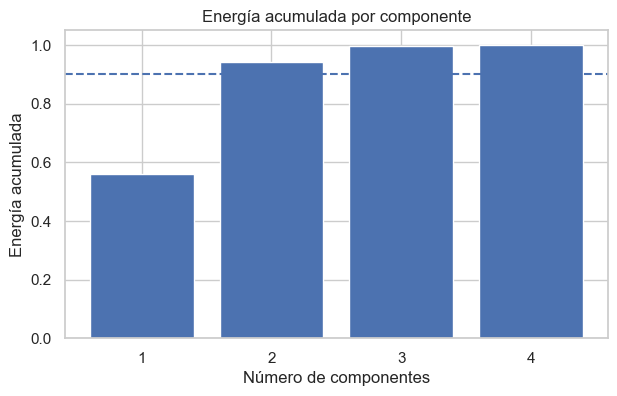

In [17]:
# TODO: Calcule la energía acumulada y grafíquela
# Pista: energy_ratio = np.cumsum(s**2) / np.sum(s**2)
energy_ratio = np.cumsum(s**2) / np.sum(s**2)

# Muestre los valores
for i, (sv, er) in enumerate(zip(s, energy_ratio), 1):
    print(f"Componente {i}: σ = {sv:.4f}, energía acumulada = {er:.4f}")

# TODO: Cree un gráfico de barras con la energía acumulada
plt.figure(figsize=(7, 4))
plt.bar(range(1, len(energy_ratio) + 1), energy_ratio)
plt.axhline(0.90, linestyle="--")
plt.xticks(range(1, len(energy_ratio) + 1))
plt.xlabel("Número de componentes")
plt.ylabel("Energía acumulada")
plt.title("Energía acumulada por componente")
plt.ylim(0, 1.05)
plt.show()

In [18]:
k_90 = np.argmax(energy_ratio >= 0.90) + 1
print(f"Componentes necesarios para retener al menos 90% de la energía: {k_90}")

Componentes necesarios para retener al menos 90% de la energía: 2


La energía acumulada muestra cuánta variabilidad de la matriz original es explicada por los primeros componentes singulares. En este caso, con 2 componentes ya se supera el 90% de la energía, lo que indica que una representación de baja dimensión captura casi toda la estructura principal de la matriz.

## 3. Del álgebra lineal al recomendador con Surprise

En recomendación **no descomponemos una matriz densa completa**: partimos de observaciones dispersas. Surprise implementa una variante de factorización entrenada **solo con ratings observados**.

### La fórmula de predicción con sesgos

$$\hat{r}_{ui} = \mu + b_u + b_i + p_u \cdot q_i^T$$

| Símbolo | Significado |
|---------|-------------|
| $\mu$ | Promedio global de todos los ratings |
| $b_u$ | Sesgo del usuario $u$ (¿tiende a calificar alto o bajo?) |
| $b_i$ | Sesgo del ítem $i$ (¿es una película generalmente bien o mal evaluada?) |
| $p_u$ | Vector latente del usuario $u$ (dimensión $k$) |
| $q_i$ | Vector latente del ítem $i$ (dimensión $k$) |

Los parámetros se aprenden minimizando el error cuadrático sobre los ratings observados con regularización:

$$\min_{p, q, b} \sum_{(u,i) \in \text{obs}} \left( r_{ui} - \hat{r}_{ui} \right)^2 + \lambda \left( \|p_u\|^2 + \|q_i\|^2 + b_u^2 + b_i^2 \right)$$

In [19]:
# Preparar los datos en el formato que espera Surprise
reader = Reader(rating_scale=(1, 5))

surprise_train = Dataset.load_from_df(train_df[["user_id", "item_id", "rating"]], reader)
surprise_validation = Dataset.load_from_df(validation_df[["user_id", "item_id", "rating"]], reader)
surprise_test = Dataset.load_from_df(test_df[["user_id", "item_id", "rating"]], reader)

### Ejercicio 3.1 — Preparar los conjuntos para Surprise

Surprise diferencia entre un **trainset** (para entrenar) y un **testset** (lista de tuplas para evaluar).

Complete los siguientes pasos:
1. Convierta `surprise_train` a trainset con `build_full_trainset()`.
2. Obtenga `train_known_ratings` con `build_testset()` sobre el trainset.
3. Convierta validación y test a testsets (primero `build_full_trainset()`, luego `build_testset()`).

In [21]:
# TODO: Prepare los conjuntos para Surprise
trainset = surprise_train.build_full_trainset()
train_known_ratings = trainset.build_testset()
validation_set = surprise_validation.build_full_trainset().build_testset()
test_set = surprise_test.build_full_trainset().build_testset()

print(f"Trainset: {trainset.n_users} usuarios, {trainset.n_items} ítems, {trainset.n_ratings} ratings")
print(f"Train (testset):      {len(train_known_ratings)} tuplas")
print(f"Validation (testset): {len(validation_set)} tuplas")
print(f"Test (testset):       {len(test_set)} tuplas")

Trainset: 911 usuarios, 1672 ítems, 81140 ratings
Train (testset):      81140 tuplas
Validation (testset): 9430 tuplas
Test (testset):       9430 tuplas


### Ejercicio 3.2 — Entrenar un primer modelo SVD

Entrene un modelo con los siguientes hiperparámetros iniciales:
- `n_factors=20` (dimensión del espacio latente)
- `n_epochs=60` (iteraciones de entrenamiento)
- `biased=True` (incluir sesgos)
- `lr_all=0.005` (tasa de aprendizaje)
- `reg_all=0.02` (regularización)
- `random_state=42`

In [22]:
# TODO: Cree e instancie el modelo SVD con los hiperparámetros indicados
algo = SVD(
    n_factors=20,
    n_epochs=60,
    biased=True,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42,
)
algo.fit(trainset)
print("Entrenamiento completado.")

Entrenamiento completado.


### Ejercicio 3.3 — Inspeccionar los parámetros aprendidos

Después del entrenamiento, el modelo almacena:
- `algo.trainset.global_mean` → $\mu$
- `algo.pu` → $P$ (matriz de factores de usuarios)
- `algo.qi` → $Q$ (matriz de factores de ítems)
- `algo.bu` → $b_u$ (vector de sesgos de usuarios)
- `algo.bi` → $b_i$ (vector de sesgos de ítems)

Recupere estos valores e imprima sus formas (*shapes*).

In [23]:
# TODO: Recupere los parámetros del modelo entrenado
global_mean = algo.trainset.global_mean
pu = algo.pu
qi = algo.qi
bu = algo.bu
bi = algo.bi

print(f"Promedio global (μ):  {global_mean:.4f}")
print(f"P (usuarios):         {pu.shape}")
print(f"Q (ítems):            {qi.shape}")
print(f"b_u (sesgo usuarios): {bu.shape}")
print(f"b_i (sesgo ítems):    {bi.shape}")

Promedio global (μ):  3.5162
P (usuarios):         (911, 20)
Q (ítems):            (1672, 20)
b_u (sesgo usuarios): (911,)
b_i (sesgo ítems):    (1672,)


### Ejercicio 3.4 — Verificar la fórmula de predicción manualmente

Tome la primera fila de `train_df` y calcule la predicción usando la fórmula:

$$\hat{r}_{ui} = \mu + b_u + b_i + p_u \cdot q_i^T$$

**Pasos:**
1. Obtenga `user_id` e `item_id` de la primera fila.
2. Conviértalos a ids internos con `trainset.to_inner_uid()` y `trainset.to_inner_iid()`.
3. Aplique la fórmula con los parámetros del modelo.
4. Compare con `algo.predict(user_id, item_id).est`.

**Pregunta:** ¿El resultado manual coincide con el de la librería?

In [24]:
# TODO: Verifique la fórmula de predicción con la primera fila de train_df
sample_row = train_df.iloc[0]
raw_u = sample_row["user_id"]
raw_i = sample_row["item_id"]
actual = sample_row["rating"]

# Convertir a ids internos
inner_u = trainset.to_inner_uid(raw_u)
inner_i = trainset.to_inner_iid(raw_i)

# Calcular predicción manual: μ + b_u + b_i + p_u · q_i^T
manual_pred = manual_pred = global_mean + bu[inner_u] + bi[inner_i] + np.dot(pu[inner_u], qi[inner_i])

# Predicción usando la librería
library_pred = algo.predict(raw_u, raw_i).est

print(f"Rating real:         {actual}")
print(f"Predicción manual:   {manual_pred:.6f}")
print(f"Predicción librería: {library_pred:.6f}")
print(f"Diferencia absoluta: {abs(manual_pred - library_pred):.2e}")

Rating real:         1
Predicción manual:   1.312228
Predicción librería: 1.312228
Diferencia absoluta: 0.00e+00


Sí, la predicción manual coincide con la de la librería. En ambos casos se está calculando la misma fórmula del modelo SVD, por lo que el resultado es el mismo.

## 4. Reconstrucción de la matriz de ratings

Una vez entrenado el modelo, podemos reconstruir **toda** la matriz de predicciones:

$$\hat{R} = \mu + b_u \mathbf{1}^T + \mathbf{1} \, b_i^T + P \cdot Q^T$$

Esto permite visualizar qué tan bien el modelo captura los ratings conocidos.

### Ejercicio 4.1 — Reconstruir la matriz de predicciones

Construya la matriz completa de predicciones a partir de los factores y sesgos del modelo.
Recorte los valores al rango [1, 5] con `np.clip`.

In [25]:
# TODO: Reconstruya la matriz usando la fórmula: μ + b_u + b_i + P @ Q^T
# Pista: reshape bu a columna (n_users, 1) y bi a fila (1, n_items) para broadcasting
bu_col = bu.reshape(-1, 1)
bi_row = bi.reshape(1, -1)

reconstruct = global_mean + bu_col + bi_row + pu @ qi.T
reconstruct = np.clip(reconstruct, 1, 5)

print(f"Forma de la matriz reconstruida: {reconstruct.shape}")

Forma de la matriz reconstruida: (911, 1672)


### Ejercicio 4.2 — Visualizar el error de reconstrucción

Construya la matriz original de ratings conocidos y compare con la reconstrucción. Visualice el error absoluto **solo en las entradas conocidas**.

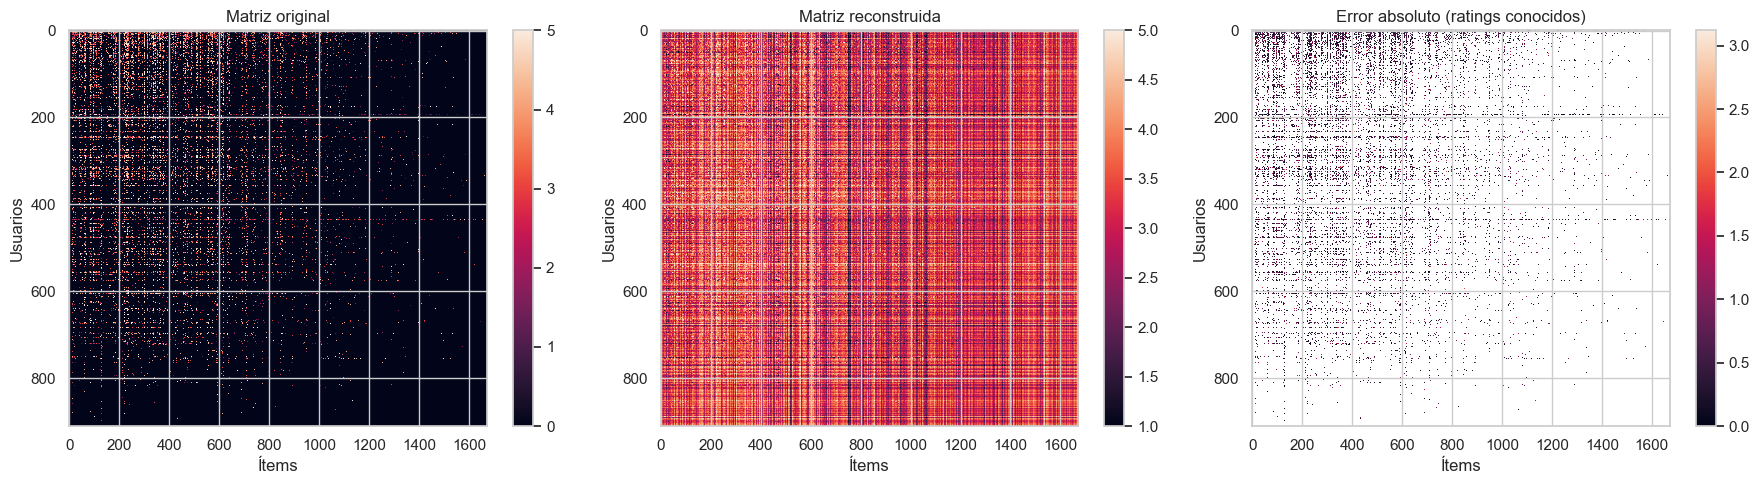

In [28]:
# TODO: Construya la matriz original y visualice el error
# 1. Cree una matriz de ceros del tamaño correcto
# 2. Rellene con los ratings usando trainset.all_ratings()
# 3. Calcule el error absoluto solo en entradas conocidas
# 4. Visualice con heatmaps
original = np.zeros((trainset.n_users, trainset.n_items))
for (u, i, r) in trainset.all_ratings():
    original[u][i] = r

known_mask = original > 0
error_matrix = np.full_like(original, np.nan, dtype=float)
error_matrix[known_mask] = np.abs(original[known_mask] - reconstruct[known_mask])

# Visualice las tres matrices: original, reconstruida, error
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(original, aspect="auto", interpolation="nearest")
axes[0].set_title("Matriz original")
axes[0].set_xlabel("Ítems")
axes[0].set_ylabel("Usuarios")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(reconstruct, aspect="auto", interpolation="nearest")
axes[1].set_title("Matriz reconstruida")
axes[1].set_xlabel("Ítems")
axes[1].set_ylabel("Usuarios")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(error_matrix, aspect="auto", interpolation="nearest")
axes[2].set_title("Error absoluto (ratings conocidos)")
axes[2].set_xlabel("Ítems")
axes[2].set_ylabel("Usuarios")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

## 5. Evaluación del modelo

Medimos el **RMSE** (Root Mean Squared Error) en los tres conjuntos.

$$\text{RMSE} = \sqrt{\frac{1}{N} \sum_{(u,i) \in \text{test}} (r_{ui} - \hat{r}_{ui})^2}$$

Un modelo bien ajustado tendrá:
- RMSE en train ≤ RMSE en validación ≈ RMSE en test.
- Si la brecha train vs validación es grande → **sobreajuste**.

In [29]:
def compute_rmse_triplet(model, train_ratings, val_set, tst_set):
    """Calcula RMSE en train, validación y test."""
    return {
        "rmse_train": accuracy.rmse(model.test(train_ratings), verbose=False),
        "rmse_validation": accuracy.rmse(model.test(val_set), verbose=False),
        "rmse_test": accuracy.rmse(model.test(tst_set), verbose=False),
    }

### Ejercicio 5.1 — Calcular RMSE del modelo entrenado

Use la función `compute_rmse_triplet` para obtener el RMSE en los tres conjuntos.

**Pregunta:** ¿Hay evidencia de sobreajuste? Justifique comparando los tres valores.

In [30]:
# TODO: Calcule el RMSE en los tres conjuntos
metrics = compute_rmse_triplet(algo, train_known_ratings, validation_set, test_set)

for name, val in metrics.items():
    print(f"{name:20s}: {val:.4f}")

rmse_train          : 0.6314
rmse_validation     : 0.9905
rmse_test           : 1.0062


Sí, hay evidencia de sobreajuste. El RMSE en entrenamiento (0.6314) es mucho menor que en validación (0.9905) y test (1.0062), lo que indica que el modelo se ajustó muy bien a los datos de entrenamiento, pero pierde desempeño al enfrentarse a datos no vistos. Como validación y test tienen valores similares, se concluye que la generalización real del modelo está alrededor de 1.0 de RMSE.

## 6. Selección de hiperparámetros

Exploramos el efecto de dos hiperparámetros clave:
- **$k$ (n_factors):** dimensión del espacio latente. Más factores = más capacidad.
- **$\lambda$ (reg_all):** regularización. Controla la complejidad del modelo.

| Configuración | Riesgo |
|---|---|
| $k$ alto + $\lambda$ bajo | Sobreajuste |
| $k$ bajo + $\lambda$ alto | Subajuste |
| Balance adecuado | Mejor generalización |

In [31]:
k_values = [5, 10, 20, 40]
reg_values = [0.0, 0.001, 0.01, 0.1, 1.0]

### Ejercicio 6.1 — Búsqueda de hiperparámetros

Complete el ciclo que entrena un modelo SVD para cada combinación de $k$ y regularización, y almacena los resultados en un DataFrame.

In [32]:
# TODO: Complete el ciclo de búsqueda de hiperparámetros
rows = []
for k in k_values:
    for reg in reg_values:
        model = SVD(
            n_factors=k,
            n_epochs=60,
            biased=True,
            lr_all=0.005,
            reg_all=reg,
            random_state=42,
        )
        model.fit(trainset)
        metrics = compute_rmse_triplet(model, train_known_ratings, validation_set, test_set)

        row = {"k": k, "reg_all": reg}
        row.update(metrics)
        rows.append(row)

results_df = pd.DataFrame(rows)
results_df.sort_values("rmse_validation").reset_index(drop=True)

,k,reg_all,rmse_train,rmse_validation,rmse_test
0,40,0.100,0.785735,0.950405,0.969081
1,20,0.100,0.818199,0.954418,0.969460
2,10,0.100,0.839585,0.954738,0.972311
3,5,0.100,0.860106,0.957276,0.974288
4,5,0.010,0.790227,0.968993,0.985423
5,5,0.001,0.787370,0.972408,0.988528
6,5,0.000,0.787106,0.972786,0.988866
7,10,0.010,0.718572,0.979443,1.001352
8,10,0.001,0.713456,0.985685,1.008636
9,10,0.000,0.712985,0.986391,1.009463


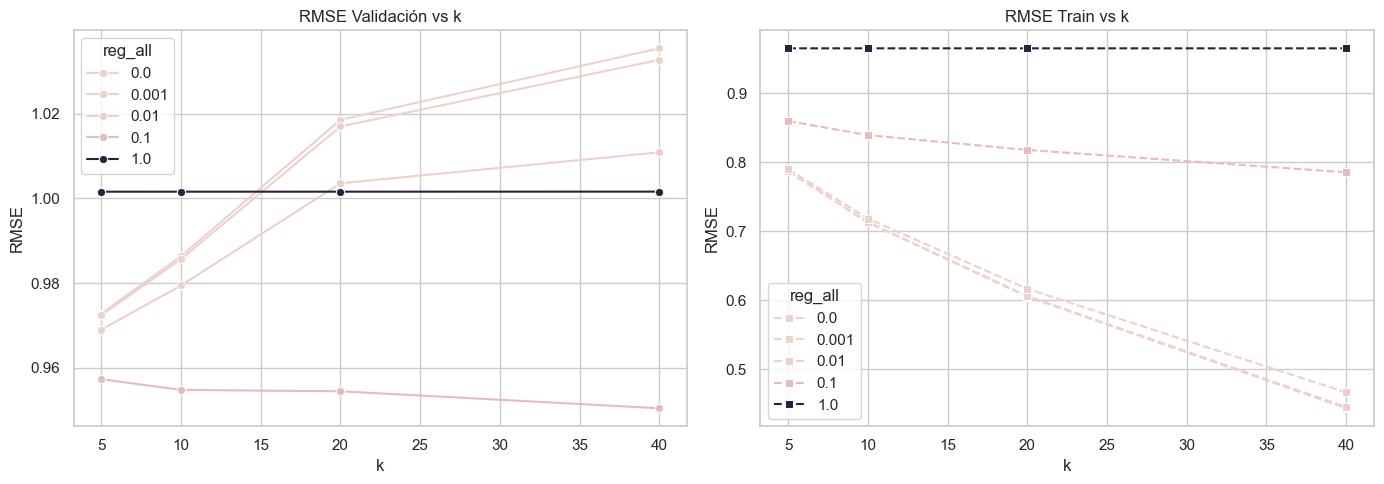

In [33]:
# Visualización del efecto de k y regularización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=results_df, x="k", y="rmse_validation", hue="reg_all", marker="o", ax=axes[0])
axes[0].set_title("RMSE Validación vs k")
axes[0].set_ylabel("RMSE")

sns.lineplot(data=results_df, x="k", y="rmse_train", hue="reg_all", marker="s", linestyle="--", ax=axes[1])
axes[1].set_title("RMSE Train vs k")
axes[1].set_ylabel("RMSE")

plt.tight_layout()
plt.show()

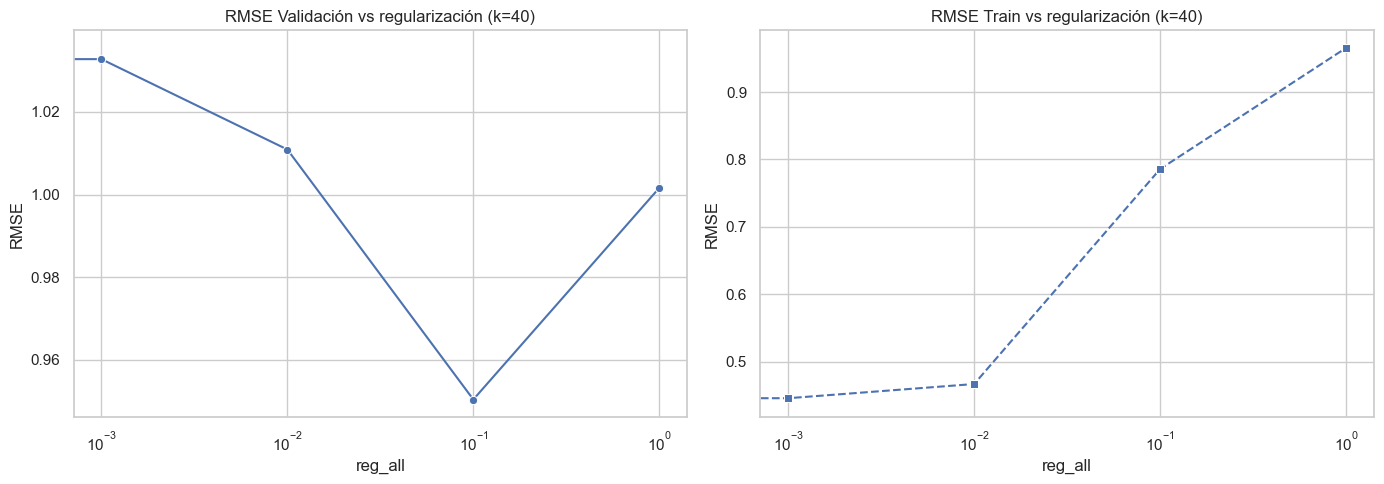

In [45]:
best_k = results_df.loc[results_df["rmse_validation"].idxmin(), "k"]
best_k_df = results_df[results_df["k"] == best_k].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=best_k_df, x="reg_all", y="rmse_validation", marker="o", ax=axes[0])
axes[0].set_title(f"RMSE Validación vs regularización (k={int(best_k)})")
axes[0].set_ylabel("RMSE")
axes[0].set_xscale("log")

sns.lineplot(data=best_k_df, x="reg_all", y="rmse_train", marker="s", linestyle="--", ax=axes[1])
axes[1].set_title(f"RMSE Train vs regularización (k={int(best_k)})")
axes[1].set_ylabel("RMSE")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()

### Ejercicio 6.2 — Seleccionar el mejor modelo

Identifique la combinación de hiperparámetros que minimiza el RMSE en validación.
Reporte su RMSE en test.

In [34]:
# TODO: Encuentre la mejor combinación de hiperparámetros
best_row = results_df.loc[results_df["rmse_validation"].idxmin()]

print("Mejor combinación según validación:")
print(f"  k       = {int(best_row['k'])}")
print(f"  reg_all = {best_row['reg_all']}")
print(f"  RMSE train:      {best_row['rmse_train']:.4f}")
print(f"  RMSE validation: {best_row['rmse_validation']:.4f}")
print(f"  RMSE test:       {best_row['rmse_test']:.4f}")

Mejor combinación según validación:
  k       = 40
  reg_all = 0.1
  RMSE train:      0.7857
  RMSE validation: 0.9504
  RMSE test:       0.9691


## 7. El papel de los sesgos (*biases*)

Los sesgos capturan tendencias sistemáticas:
- **$b_u$**: si un usuario tiende a calificar generosamente ($b_u > 0$) o severamente ($b_u < 0$).
- **$b_i$**: si un ítem tiende a recibir ratings altos o bajos.

Sin sesgos, los factores latentes tendrían que absorber estas tendencias, desperdiciendo capacidad.

### Ejercicio 7.1 — Comparar modelos con y sin sesgos

Entrene un modelo con `biased=False` usando los mismos hiperparámetros que el modelo original (n_factors=20, n_epochs=60, lr_all=0.005, reg_all=0.02).
Compare el RMSE en los tres conjuntos.

**Pregunta:** ¿Qué efecto tiene remover los sesgos?

In [35]:
# TODO: Entrene un modelo SIN sesgos y compare con el modelo con sesgos
algo_no_bias = SVD(
    n_factors=20,
    n_epochs=60,
    biased=False,  # ¿Qué valor usar para desactivar sesgos?
    lr_all=0.005,
    reg_all=0.02,
    random_state=42,
)
algo_no_bias.fit(trainset)

metrics_bias = compute_rmse_triplet(algo, train_known_ratings, validation_set, test_set)
metrics_no_bias = compute_rmse_triplet(algo_no_bias, train_known_ratings, validation_set, test_set)

comparison = pd.DataFrame({"Con sesgos": metrics_bias, "Sin sesgos": metrics_no_bias})
comparison

,Con sesgos,Sin sesgos
rmse_train,0.631370,0.634359
rmse_validation,0.990505,1.050682
rmse_test,1.006234,1.069405


Remover los sesgos normalmente empeora el desempeño del modelo. Esto ocurre porque el modelo ya no puede capturar explícitamente tendencias generales de los usuarios y de los ítems, como usuarios que califican siempre alto o películas que suelen gustar más a todos. Sin sesgos, esa información tiene que ser absorbida por los factores latentes, lo que hace el modelo menos eficiente y suele aumentar el RMSE.

### Ejercicio 7.2 — Visualizar los sesgos aprendidos

Visualice la distribución de $b_u$ y $b_i$ del modelo con sesgos.
Identifique el ítem con mayor sesgo positivo y busque a qué película corresponde.

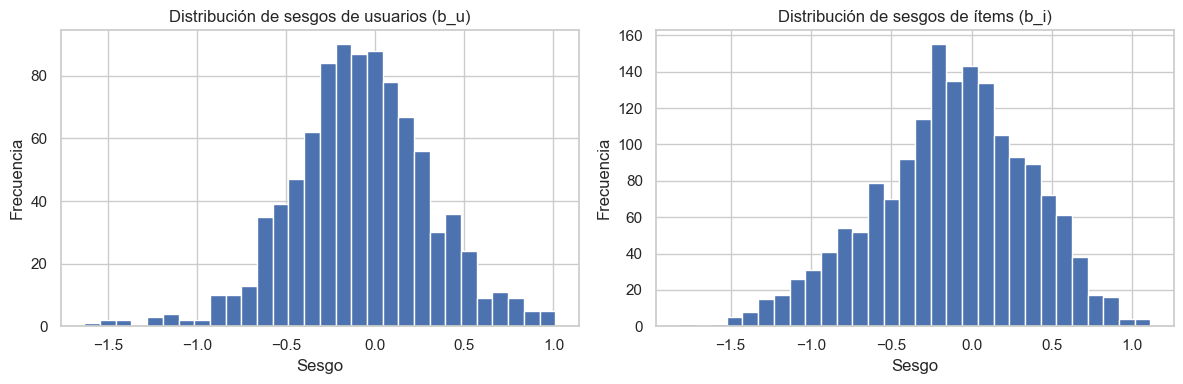

Ítem con mayor b_i: raw_id=1449, b_i=1.1129
      movieId                       title  genres
1409     1449  Waiting for Guffman (1996)  Comedy


In [37]:
# TODO: Visualice la distribución de sesgos bu y bi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# TODO: Histograma de bu en axes[0]
axes[0].hist(bu, bins=30)
axes[0].set_title("Distribución de sesgos de usuarios (b_u)")
axes[0].set_xlabel("Sesgo")
axes[0].set_ylabel("Frecuencia")

# TODO: Histograma de bi en axes[1]
axes[1].hist(bi, bins=30)
axes[1].set_title("Distribución de sesgos de ítems (b_i)")
axes[1].set_xlabel("Sesgo")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# TODO: Encuentre la película con mayor sesgo positivo
max_bias_inner = np.argmax(bi)
max_bias_raw = trainset.to_raw_iid(max_bias_inner)
print(f"Ítem con mayor b_i: raw_id={max_bias_raw}, b_i={bi[max_bias_inner]:.4f}")
print(movies_df.loc[movies_df["movieId"] == max_bias_raw, ["movieId", "title", "genres"]])

## 8. Ejercicio final: SVD con scikit-learn (TruncatedSVD)

En esta sección dejamos Surprise y usamos `TruncatedSVD` de **scikit-learn**. No es un recomendador especializado, pero permite:
- Practicar con una librería de uso general en machine learning.
- Entender las diferencias con una factorización optimizada para datos dispersos.
- Conectar recomendación con pipelines modernos de ML.

### Diferencias clave con Surprise SVD

| Aspecto | Surprise SVD | scikit-learn TruncatedSVD |
|---------|-------------|---------------------------|
| Entrenamiento | Solo sobre ratings observados (SGD) | Sobre la matriz completa (densa o dispersa) |
| Sesgos | Modelados explícitamente ($b_u$, $b_i$) | No tiene sesgos |
| Datos faltantes | Ignorados durante el entrenamiento | Tratados como 0 (o valor de centrado) |
| Uso principal | Recomendación | Reducción de dimensionalidad general |

### Ejercicio 8.1 — Construir la matriz densa usuario-item

Convierta los ratings del conjunto de entrenamiento a una matriz densa donde las filas son usuarios, las columnas son ítems y las entradas son los ratings (0 si no hay rating).

In [38]:
# TODO: Construya la matriz densa usuario-item
# Pista: use pd.factorize() para crear índices contiguos
user_codes, user_index = pd.factorize(train_df["user_id"], sort=True)
item_codes, item_index = pd.factorize(train_df["item_id"], sort=True)

dense_ratings = np.zeros((len(user_index), len(item_index)), dtype=float)
# TODO: Rellene la matriz con los ratings
dense_ratings[user_codes, item_codes] = train_df["rating"].to_numpy()
observed_mask = dense_ratings > 0

# Mapeos para convertir entre IDs y posiciones
user_id_to_pos = {uid: pos for pos, uid in enumerate(user_index)}
item_pos_to_id = {pos: iid for pos, iid in enumerate(item_index)}

print(f"Matriz densa: {dense_ratings.shape}")
print(f"Ratings observados: {observed_mask.sum():,} de {dense_ratings.size:,}")

Matriz densa: (911, 1672)
Ratings observados: 81,140 de 1,523,192


### Ejercicio 8.2 — Centrar la matriz por promedios de ítem

Antes de aplicar SVD, centramos los datos. Calculamos el **promedio de cada ítem** solo con entradas observadas y lo restamos.

**Pasos:**
1. Cuente cuántas observaciones tiene cada ítem.
2. Calcule el promedio de cada ítem (solo entradas observadas).
3. Centre la matriz restando el promedio donde hay rating (dejando 0 donde no lo hay).

In [39]:
# TODO: Centre la matriz por promedios de ítem
item_counts = observed_mask.sum(axis=0)
item_means = np.divide(
    dense_ratings.sum(axis=0),
    item_counts,
    out=np.zeros(dense_ratings.shape[1], dtype=float),
    where=item_counts > 0,
)
# TODO: Cree la matriz centrada restando item_means donde hay rating
centered_dense = np.where(observed_mask, dense_ratings - item_means, 0.0)

print(f"Promedio de los primeros 5 ítems: {np.round(item_means[:5], 3)}")

Promedio de los primeros 5 ítems: [3.852 3.209 3.053 3.541 3.28 ]


### Ejercicio 8.3 — Aplicar TruncatedSVD y reconstruir

Ajuste `TruncatedSVD(n_components=20, random_state=42)` sobre la matriz centrada.
Luego reconstruya la matriz sumando de vuelta los promedios de ítem y recorte al rango [1, 5].

In [40]:
# TODO: Aplique TruncatedSVD y reconstruya la matriz
modern_svd = TruncatedSVD(n_components=20, random_state=42)
user_latent = modern_svd.fit_transform(centered_dense)

# TODO: Reconstruya sumando promedios de ítem y recorte al rango [1, 5]
reconstructed_dense = user_latent @ modern_svd.components_ + item_means
reconstructed_dense = np.clip(reconstructed_dense, 1, 5)

explained = modern_svd.explained_variance_ratio_.sum()
print(f"Varianza explicada acumulada: {explained:.2%}")

Varianza explicada acumulada: 25.42%


### Ejercicio 8.4 — Analizar la varianza explicada por componente

Grafique la varianza explicada acumulada para entender cuántos componentes son suficientes.

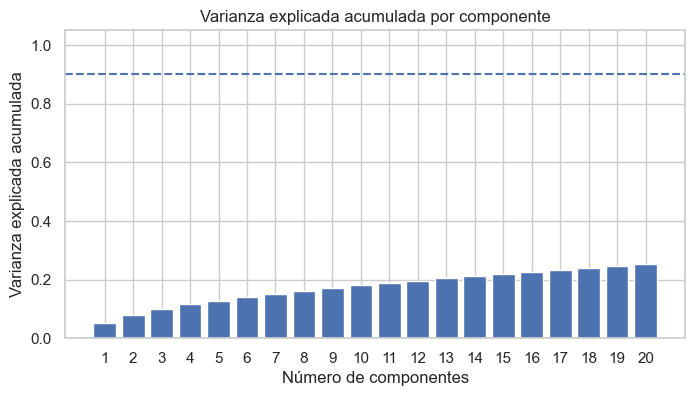

In [41]:
# TODO: Grafique la varianza explicada acumulada
cum_var = np.cumsum(modern_svd.explained_variance_ratio_)

# TODO: Cree un gráfico de barras con cum_var
# Agregue una línea horizontal en 90% como referencia
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(cum_var) + 1), cum_var)
plt.axhline(0.90, linestyle="--")
plt.xticks(range(1, len(cum_var) + 1))
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada por componente")
plt.ylim(0, 1.05)
plt.show()

### Ejercicio 8.5 — Generar Top-10 recomendaciones

Para el usuario con más ratings en el conjunto de entrenamiento:
1. Identifique los ítems que ya ha visto.
2. Obtenga los puntajes predichos para los ítems no vistos.
3. Ordene de mayor a menor y muestre los 10 primeros con sus títulos.

In [42]:
# TODO: Genere el top-10 de recomendaciones para el usuario más activo
target_user = train_df["user_id"].value_counts().idxmax()
user_pos = user_id_to_pos[target_user]
seen_items = set(train_df.loc[train_df["user_id"] == target_user, "item_id"])

# TODO: Cree un DataFrame con los puntajes y filtre los ítems ya vistos
candidate_scores = pd.DataFrame({
    "movieId": [item_pos_to_id[pos] for pos in range(reconstructed_dense.shape[1])],
    "score": reconstructed_dense[user_pos]
})
candidate_scores = candidate_scores[~candidate_scores["movieId"].isin(seen_items)]
candidate_scores = candidate_scores.sort_values("score", ascending=False)

# TODO: Obtenga el top-10 y una con movies_df para ver títulos
top_10 = candidate_scores.head(10).merge(movies_df, on="movieId", how="left")

print(f"Recomendaciones para usuario {target_user} (top-10):")
top_10[["movieId", "title", "score"]]

Recomendaciones para usuario 405 (top-10):


,movieId,title,score
0,1467,Salut cousin! (1996),5.0
1,1656,Swept from the Sea (1997),5.0
2,814,"Boy Called Hate, A (1995)",5.0
3,1189,"Thin Blue Line, The (1988)",5.0
4,1536,NaN,5.0
5,1201,"Good, the Bad and the Ugly, The (Buono, il bru...",5.0
6,1122,Plutonium Circus (1995),5.0
7,1293,Gandhi (1982),5.0
8,1500,Grosse Pointe Blank (1997),5.0
9,1599,Steel (1997),5.0


### Ejercicio 8.6 — Evaluar TruncatedSVD en el conjunto de test

Calcule el RMSE de las predicciones de TruncatedSVD **solo en las entradas del conjunto de test**.
Compare con el RMSE que obtuvo con Surprise.

In [44]:
# TODO: Evalúe TruncatedSVD en el conjunto de test
# Para cada fila del test_df, busque la predicción en reconstructed_dense
test_preds = []
test_actuals = []

for _, row in test_df.iterrows():
    uid = row["user_id"]
    iid = row["item_id"]
    if uid in user_id_to_pos and iid in set(item_index):
        u_pos = user_id_to_pos[uid]
        i_pos = np.where(item_index == iid)[0]
        if len(i_pos) > 0:
            # TODO: Obtenga la predicción de la matriz reconstruida
            test_preds.append(reconstructed_dense[u_pos, i_pos[0]])
            test_actuals.append(row["rating"])

rmse_sklearn = np.sqrt(mean_squared_error(test_actuals, test_preds))
print(f"RMSE TruncatedSVD en test: {rmse_sklearn:.4f}")
print(f"RMSE Surprise SVD en test: {metrics['rmse_test']:.4f}")

RMSE TruncatedSVD en test: 1.0147
RMSE Surprise SVD en test: 1.0131


## 9. Cierre y preguntas de reflexión

### Resumen de lo aprendido

| Sección | Concepto clave |
|---------|----------------|
| 1. Datos | La matriz usuario-item es extremadamente dispersa (~95%+) |
| 2. SVD algebraica | SVD descompone en factores; la aproximación de rango bajo retiene la estructura dominante |
| 3. Surprise SVD | En recomendación, los factores se aprenden con SGD sobre ratings observados, incluyendo sesgos |
| 4. Reconstrucción | La predicción = μ + b_u + b_i + p_u · q_i^T |
| 5. Evaluación | RMSE en validación detecta sobreajuste; la brecha train–val es clave |
| 6. Hiperparámetros | k controla capacidad, λ controla complejidad; el balance se busca en validación |
| 7. Sesgos | Capturan tendencias sistemáticas; sin ellos, los factores pierden calidad |
| 8. scikit-learn | TruncatedSVD es general pero no modela sesgos ni faltantes como Surprise |

### Preguntas de seguimiento
1. Si aumentamos mucho $k$, ¿qué parte del error esperamos que baje primero y por qué?
2. ¿Por qué agregar sesgos ayuda incluso antes de que los factores latentes aprendan afinidades complejas?
3. ¿Qué información pierde `TruncatedSVD` cuando tratamos los faltantes como ceros centrados?
4. ¿En qué escenarios una librería especializada como Surprise sigue siendo preferible frente a una descomposición genérica?
5. ¿Cómo afectaría usar una métrica diferente (e.g., MAE) a la selección de hiperparámetros?

**1. Si aumentamos mucho 𝑘, ¿qué parte del error esperamos que baje primero y por qué?**

Primero suele bajar el error de entrenamiento, porque al aumentar 𝑘 el modelo tiene más capacidad para ajustarse a los datos observados. Con más factores latentes puede representar mejor patrones específicos e incluso detalles particulares del train. El problema es que, si 𝑘 crece demasiado, esa mejora puede no trasladarse a validación y test, produciendo sobreajuste.

**2. ¿Por qué agregar sesgos ayuda incluso antes de que los factores latentes aprendan afinidades complejas?**

Porque los sesgos capturan de forma directa tendencias simples pero muy importantes: usuarios que califican alto o bajo en general, e ítems que suelen gustar más o menos a todos. Sin sesgos, los factores latentes tendrían que gastar capacidad modelando esas diferencias básicas. Al incluirlos, el modelo explica primero lo más evidente y deja a los factores la tarea de aprender relaciones más complejas entre usuarios e ítems.

**3. ¿Qué información pierde TruncatedSVD cuando tratamos los faltantes como ceros centrados?**

Pierde la distinción entre “no observado” y “valor realmente bajo”. Al tratar faltantes como ceros, el método interpreta ausencia de rating como si fuera una entrada válida sin preferencia, lo cual distorsiona la estructura real de la matriz. En recomendación eso es problemático, porque la mayoría de celdas vacías no significan rechazo, sino simplemente que el usuario nunca interactuó con ese ítem.

**4. ¿En qué escenarios una librería especializada como Surprise sigue siendo preferible frente a una descomposición genérica?**

Es preferible cuando trabajamos con datos de recomendación dispersos, porque está diseñada para aprender solo desde ratings observados, manejar mejor faltantes y modelar sesgos explícitos. También es mejor cuando el objetivo principal es predecir ratings o generar recomendaciones con buena precisión. Una descomposición genérica como TruncatedSVD sirve para explorar o reducir dimensionalidad, pero no está optimizada para este tipo de problema.

**5. ¿Cómo afectaría usar una métrica diferente, por ejemplo MAE, a la selección de hiperparámetros?**

Podría cambiar cuál configuración se considera mejor. RMSE castiga más los errores grandes porque eleva al cuadrado las diferencias, mientras que MAE trata todos los errores de forma lineal. Entonces, un modelo que comete pocos errores muy grandes puede verse peor en RMSE que en MAE. Por eso, según la métrica elegida, podrían variar los hiperparámetros óptimos, especialmente en el balance entre capacidad del modelo y regularización.